# 01 — Data Download & Preprocessing
## Fraud Detection MLOps Platform

This notebook:
1. Downloads the PaySim dataset from Kaggle
2. Explores the data (EDA)
3. Cleans and preprocesses it
4. Saves train/test splits ready for model training

### Before running:
- Go to https://www.kaggle.com/settings -> API -> "Create Legacy API Key"
- This downloads a `kaggle.json` file to your computer
- Copy `kaggle.json` to C:\Users\WindowsUsername\.kaggle\
- Upload it when prompted in Cell 3 below

---
### install kaggle

In [1]:
# Install kaggle package
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle", "-q"])
print("kaggle package ready")

kaggle package ready


---
### Upload kaggle.json token

In [9]:
import os
from pathlib import Path

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)

# Check if kaggle.json exists
kaggle_json = kaggle_dir / "kaggle.json"

if kaggle_json.exists():
    print("kaggle.json found at:", kaggle_json)
else:
    print("kaggle.json NOT found!")
    print()
    print("Do this:")
    print("1. Go to https://www.kaggle.com/settings")
    print("2. Scroll to API section -> click 'Create Legacy API Key'")
    print("3. It downloads kaggle.json to your Downloads folder")
    print(f"4. Copy that file to:  {kaggle_dir}" )
    print("5. Re-run this cell")

kaggle.json found at: C:\Users\Dell\.kaggle\kaggle.json


---
---
## Step 1 — Download Dataset
Downloads the PaySim synthetic financial dataset from Kaggle.
- 6.3 million transactions
- Clean named columns
- ~470 MB compressed

In [10]:
import os
from pathlib import Path

# Create data directory inside the project
data_dir = Path("../data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

# Download using Kaggle API
# Dataset: https://www.kaggle.com/datasets/ealaxi/paysim1
os.system(f"kaggle datasets download -d ealaxi/paysim1 -p {data_dir} --unzip")

# Check what was downloaded
files_found = list(data_dir.glob("*"))
print("Files downloaded:")
for f in files_found:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"   {f.name}  ({size_mb:.1f} MB)")

Files downloaded:
   PS_20174392719_1491204439457_log.csv  (470.7 MB)


---
---
## Step 2 — Load & First Look at the Data
Load the CSV and understand its structure before any cleaning.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the full dataset
csv_path = "../data/raw/PS_20174392719_1491204439457_log.csv"
print("Loading dataset (this may take 30–60 seconds for 6M rows)...")

df = pd.read_csv(csv_path)
print(f"Loaded! Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loading dataset (this may take 30–60 seconds for 6M rows)...
Loaded! Shape: 6,362,620 rows × 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
# Column names, types, and missing values at a glance
print("=" * 50)
print("COLUMN INFO")
print("=" * 50)
print(df.dtypes)
print()
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print()
print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe()

COLUMN INFO
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

MISSING VALUES
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

BASIC STATISTICS


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


---
### Fraud distribution

Fraud label distribution:
  Not fraud (0): 6,354,407  (99.87%)
  Fraud     (1): 8,213  (0.13%)

This is a heavily imbalanced dataset — This will be handled during training with SMOTE.


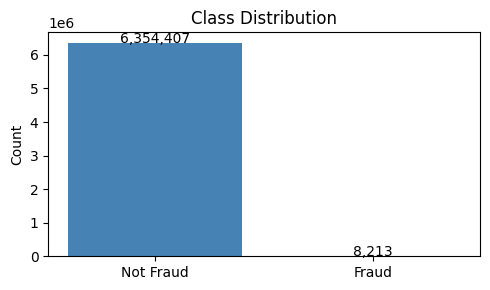

In [13]:
# How imbalanced is the target label
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print("Fraud label distribution:")
print(f"  Not fraud (0): {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"  Fraud     (1): {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)")
print()
print("This is a heavily imbalanced dataset — This will be handled during training with SMOTE.")

# Quick bar chart
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 10000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
### Transaction types

In [14]:
# What transaction types exist, and which types contain fraud
print("Transaction types in dataset:")
print(df['type'].value_counts())
print()

# Fraud only happens in certain types
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
print("Fraud count by transaction type:")
print(fraud_by_type)
print()
print("Fraud only occurs in TRANSFER and CASH_OUT — This will be used as a feature.")

Transaction types in dataset:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud count by transaction type:
type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64

Fraud only occurs in TRANSFER and CASH_OUT — This will be used as a feature.


---
---
## Step 3 — Clean & Preprocess

Steps:
1. **Filter** to only fraud-relevant transaction types (TRANSFER, CASH_OUT)
2. **Drop** columns that are not useful for ML (account names, isFlaggedFraud)
3. **Encode** the `type` column (text -> number)
4. **Engineer** new features that help detect fraud
5. **Sample** 200k rows so training stays fast in development

---
### Filter to relevant types

In [15]:
# Keep only TRANSFER and CASH_OUT — fraud only happens in these
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"Original rows:  {len(df):,}")
print(f"Filtered rows:  {len(df_filtered):,}")
print(f"Fraud in filtered set: {df_filtered['isFraud'].sum():,}")
print(f"Fraud rate after filter: {df_filtered['isFraud'].mean()*100:.3f}%")

Original rows:  6,362,620
Filtered rows:  2,770,409
Fraud in filtered set: 8,213
Fraud rate after filter: 0.296%


---
### Drop useless columns

In [16]:
# Drop columns that don't help the model:
# - nameOrig / nameDest: account IDs, too high cardinality, no signal
# - isFlaggedFraud: a simple rule-based flag, not a real feature (data leakage risk)

cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df_clean = df_filtered.drop(columns=cols_to_drop)

print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


---
### Encode transaction type

In [17]:
# Encode 'type' as binary: TRANSFER=1, CASH_OUT=0
df_clean['type_encoded'] = (df_clean['type'] == 'TRANSFER').astype(int)
df_clean = df_clean.drop(columns=['type'])

print("type_encoded value counts:")
print(df_clean['type_encoded'].value_counts())

type_encoded value counts:
type_encoded
0    2237500
1     532909
Name: count, dtype: int64


---
### Feature engineering

In [18]:
# Engineer new features that capture suspicious patterns

# 1. Balance difference for sender — how much did their balance change
df_clean['orig_balance_diff'] = df_clean['oldbalanceOrg'] - df_clean['newbalanceOrig']

# 2. Balance difference for recipient
df_clean['dest_balance_diff'] = df_clean['newbalanceDest'] - df_clean['oldbalanceDest']

# 3. Did the sender's account go to exactly zero (common in fraud)
df_clean['orig_balance_zero'] = (df_clean['newbalanceOrig'] == 0).astype(int)

# 4. Amount relative to sender's original balance (transaction size ratio)
# Avoid divide-by-zero with a small epsilon
df_clean['amount_to_balance_ratio'] = df_clean['amount'] / (df_clean['oldbalanceOrg'] + 1e-9)
# Cap extreme ratios at 10 to avoid wild outliers
df_clean['amount_to_balance_ratio'] = df_clean['amount_to_balance_ratio'].clip(upper=10)

# 5. Hour of day (step in dataset = hour of simulation, mod 24)
df_clean['hour_of_day'] = df_clean['step'] % 24

print("New features added. All columns now:")
print(df_clean.columns.tolist())
print()
df_clean.head()

New features added. All columns now:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_encoded', 'orig_balance_diff', 'dest_balance_diff', 'orig_balance_zero', 'amount_to_balance_ratio', 'hour_of_day']



,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_encoded,orig_balance_diff,dest_balance_diff,orig_balance_zero,amount_to_balance_ratio,hour_of_day
2,1,181.00,181.0,0.0,0.0,0.00,1,1,181.0,0.00,1,1.0,1
3,1,181.00,181.0,0.0,21182.0,0.00,1,0,181.0,-21182.00,1,1.0,1
15,1,229133.94,15325.0,0.0,5083.0,51513.44,0,0,15325.0,46430.44,1,10.0,1
19,1,215310.30,705.0,0.0,22425.0,0.00,0,1,705.0,-22425.00,1,10.0,1
24,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,1,10835.0,2712905.89,1,10.0,1


---
### Check for nulls and info

In [19]:
# Sanity check — no nulls or infinite values should exist after our transformations
print("Null values per column:")
print(df_clean.isnull().sum())
print()

# Check for infinite values (can appear from division)
inf_check = df_clean.replace([np.inf, -np.inf], np.nan).isnull().sum()
print("Infinite values per column (shown as NaN):")
print(inf_check[inf_check > 0] if inf_check.sum() > 0 else "None")

Null values per column:
step                       0
amount                     0
oldbalanceOrg              0
newbalanceOrig             0
oldbalanceDest             0
newbalanceDest             0
isFraud                    0
type_encoded               0
orig_balance_diff          0
dest_balance_diff          0
orig_balance_zero          0
amount_to_balance_ratio    0
hour_of_day                0
dtype: int64

Infinite values per column (shown as NaN):
None


---
### Correlation heatmap

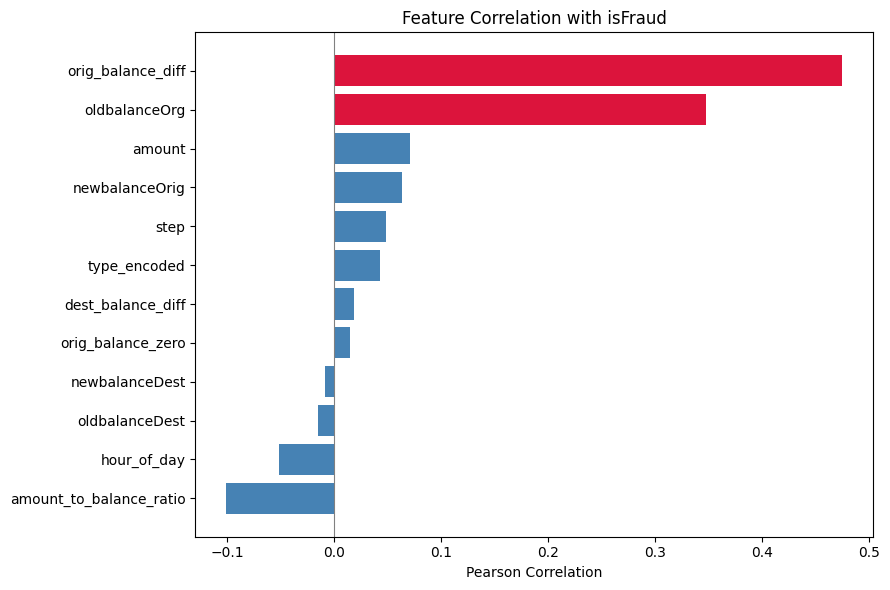

Top positively correlated features with fraud:
step                 0.048671
newbalanceOrig       0.063557
amount               0.070660
oldbalanceOrg        0.347582
orig_balance_diff    0.474628
Name: isFraud, dtype: float64


In [20]:
# Correlation of features with the fraud label
# Helps to see which engineered features are most predictive

plt.figure(figsize=(9, 6))
corr = df_clean.corr(numeric_only=True)['isFraud'].drop('isFraud').sort_values()

colors = ['crimson' if v > 0.1 else 'steelblue' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(x=0, color='gray', linewidth=0.8)
plt.title('Feature Correlation with isFraud')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top positively correlated features with fraud:")
print(corr.tail(5))

---
---
## Step 4 — Sample & Split

Sample 200,000 rows for faster development. The sample is **stratified** — meaning the fraud-to-non-fraud ratio is preserved.

Then split into:
- **Train set** (80%) — for model training
- **Test set** (20%) — held out for evaluation

In [21]:
from sklearn.model_selection import train_test_split

# Stratified sample of 200k rows (preserves fraud ratio)
SAMPLE_SIZE = 200_000
RANDOM_STATE = 42

df_sample = df_clean.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(frac=SAMPLE_SIZE / len(df_clean), random_state=RANDOM_STATE)
).reset_index(drop=True)

# Make sure we have exactly SAMPLE_SIZE (rounding can cause off-by-one)
df_sample = df_sample.sample(n=min(SAMPLE_SIZE, len(df_sample)), random_state=RANDOM_STATE)

print(f"Sample size: {len(df_sample):,}")
print(f"Fraud in sample: {df_sample['isFraud'].sum():,}  ({df_sample['isFraud'].mean()*100:.3f}%)")
print()

# Define features (X) and target (y)
FEATURES = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'type_encoded',
    'orig_balance_diff', 'dest_balance_diff',
    'orig_balance_zero', 'amount_to_balance_ratio', 'hour_of_day'
]
TARGET = 'isFraud'

X = df_sample[FEATURES]
y = df_sample[TARGET]

# 80/20 train-test split, stratified so both sets have same fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape}  |  Fraud in train: {y_train.sum():,}")
print(f"X_test:  {X_test.shape}   |  Fraud in test:  {y_test.sum():,}")

C:\Users\Dell\AppData\Local\Temp\ipykernel_6892\3500304990.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_clean.groupby('isFraud', group_keys=False).apply(


Sample size: 200,000
Fraud in sample: 593  (0.297%)

X_train: (160000, 12)  |  Fraud in train: 474
X_test:  (40000, 12)   |  Fraud in test:  119


---
---
## Step 5 — Save Processed Data

Save everything to `data/processed/` so the training notebook can load it directly — no need to re-run preprocessing every time.

In [22]:
from pathlib import Path

# Create processed data directory
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save train/test splits
X_train.to_csv(processed_dir / "X_train.csv", index=False)
X_test.to_csv(processed_dir /  "X_test.csv",  index=False)
y_train.to_csv(processed_dir / "y_train.csv", index=False)
y_test.to_csv(processed_dir /  "y_test.csv",  index=False)

# Also save feature names for use in the API later
import json
with open(processed_dir / "feature_names.json", "w") as f:
    json.dump(FEATURES, f)

print("Saved to data/processed/")
print("Files:")
for f in sorted(processed_dir.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name}  ({size_kb:.1f} KB)")

Saved to data/processed/
Files:
   feature_names.json  (0.2 KB)
   X_test.csv  (3240.6 KB)
   X_train.csv  (12966.2 KB)
   y_test.csv  (117.2 KB)
   y_train.csv  (468.8 KB)


---
### Final summary

In [23]:
print("=" * 50)
print("PREPROCESSING COMPLETE — SUMMARY")
print("=" * 50)
print(f"Original dataset rows:    {len(df):,}")
print(f"After type filter:        {len(df_filtered):,}")
print(f"Sample used:              {len(df_sample):,}")
print(f"Features:                 {len(FEATURES)}")
print(f"Training samples:         {len(X_train):,}")
print(f"Test samples:             {len(X_test):,}")
print(f"Fraud rate (sample):      {y.mean()*100:.3f}%")
print()

PREPROCESSING COMPLETE — SUMMARY
Original dataset rows:    6,362,620
After type filter:        2,770,409
Sample used:              200,000
Features:                 12
Training samples:         160,000
Test samples:             40,000
Fraud rate (sample):      0.297%



---
---